# OLCI L3 matchups on all PACE-matched profiles

Scale the one-day smoke test to **every unique date** in the CHLA-Z PACE-matched table.

For each `profile_id`, sample NASA delayed-mode OLCI L3 mapped Rrs (daily 4 km) at `lat` / `lon` / `time` for the 11 water bands:
400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709 nm.

S3A is used when the pixel is finite; otherwise S3B. Writes one row per `profile_id` (OOI sometimes repeats the same id at the same place and day).

Runtime is hours (~600 days × up to 22 granules). The loop **checkpoints** so you can stop and re-run. Kernel: `gobgc`. Needs `~/.netrc`.

In [1]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import earthaccess

warnings.filterwarnings("ignore", category=FutureWarning, module="earthaccess")

OLCI_BANDS = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]
SHORT = {"S3A": "OLCIS3A_L3m_ERR_RRS", "S3B": "OLCIS3B_L3m_ERR_RRS"}

# None = all unique days. Set to 5 to test the loop.
LIMIT_DAYS = None
CHECKPOINT_EVERY = 10

DATA = Path("/Users/nmamnun/GO-BGC-Workshop/chla-z/brt_training_data")
HERE = Path("/Users/nmamnun/GO-BGC-Workshop/2026-go-bgc-hackweek/contributor_folders/nama")
if not (DATA / "CHLA_argo_profiles_plus_PACE.parquet").is_file():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        cand = p.parent / "chla-z" / "brt_training_data"
        if (cand / "CHLA_argo_profiles_plus_PACE.parquet").is_file():
            DATA = cand
        if (p / "contributor_folders" / "nama").is_dir():
            HERE = p / "contributor_folders" / "nama"

OUT = HERE / "olci_l3_matchups.parquet"
CKPT = HERE / "olci_l3_matchups_checkpoint.parquet"
print("DATA:", DATA)
print("OUT:", OUT)
print("LIMIT_DAYS:", LIMIT_DAYS)

DATA: /Users/nmamnun/GO-BGC-Workshop/chla-z/brt_training_data
OUT: /Users/nmamnun/GO-BGC-Workshop/2026-go-bgc-hackweek/contributor_folders/nama/olci_l3_matchups.parquet
LIMIT_DAYS: None


/opt/homebrew/Caskroom/miniforge/base/envs/gobgc/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. PACE-matched profiles and unique days

In [2]:
def load_pace_matched(data_dir: Path) -> pd.DataFrame:
    argo = pd.read_parquet(data_dir / "CHLA_argo_profiles_plus_PACE.parquet")
    argo = argo.rename(columns={"LATITUDE": "lat", "LONGITUDE": "lon", "TIME": "time"})
    argo["source"] = "argo"
    ooi = pd.read_parquet(data_dir / "CHLA_ooi_profiles_plus_PACE.parquet")
    ooi["source"] = "ooi"
    rrs_cols = [c for c in argo.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
    keep = ["profile_id", "time", "lat", "lon", "source"]
    frames = []
    for df in (argo, ooi):
        sub = df[keep + rrs_cols].dropna(subset=rrs_cols, how="all")[keep].copy()
        frames.append(sub)
    out = pd.concat(frames, ignore_index=True)
    out["time"] = pd.to_datetime(out["time"], utc=True)
    out["day"] = out["time"].dt.normalize()
    # OOI repeats the same profile_id at the same lat/lon/day.
    n0 = len(out)
    out = out.drop_duplicates("profile_id").reset_index(drop=True)
    print(f"PACE-matched rows {n0} -> {len(out)} unique profile_id")
    return out

pts = load_pace_matched(DATA)
days = np.sort(pts["day"].unique())
if LIMIT_DAYS is not None:
    days = days[: int(LIMIT_DAYS)]
print(f"unique days to process: {len(days)}  ({pd.Timestamp(days[0]).date()} .. {pd.Timestamp(days[-1]).date()})")
print(pts.groupby("source").size())

PACE-matched rows 5540 -> 4732 unique profile_id
unique days to process: 597  (2024-03-05 .. 2025-12-02)
source
argo    2770
ooi     1962
dtype: int64


## 2. Earthdata login and granule index

One CMR search per satellite × band over the date range. Index by calendar day so the match loop does not search again.

In [3]:
auth = earthaccess.login()
if not auth.authenticated:
    auth = earthaccess.login(strategy="interactive", persist=True)
print("authenticated:", auth.authenticated)

YMD_RE = re.compile(r"(\d{8})\.L3m\.DAY")


def granule_ymd(g) -> str | None:
    link = (g.data_links() or [""])[0]
    m = YMD_RE.search(link)
    return m.group(1) if m else None


def build_index(days) -> dict:
    t0 = pd.Timestamp(days.min()).strftime("%Y-%m-%d")
    t1 = pd.Timestamp(days.max()).strftime("%Y-%m-%d")
    want = {pd.Timestamp(d).strftime("%Y%m%d") for d in days}
    index = {sat: {} for sat in SHORT}
    for sat, short_name in SHORT.items():
        for nm in OLCI_BANDS:
            results = earthaccess.search_data(
                short_name=short_name,
                temporal=(t0, t1),
                granule_name=f"*.DAY.*.Rrs_{nm}.4km.nc",
                count=5000,
            )
            n_keep = 0
            for g in results:
                ymd = granule_ymd(g)
                if ymd is None or ymd not in want:
                    continue
                index[sat].setdefault(ymd, {})[nm] = g
                n_keep += 1
            print(f"{sat} Rrs_{nm}: {len(results)} hits, {n_keep} on our days")
    return index

index = build_index(days)
for sat in SHORT:
    n_days = len(index[sat])
    n_full = sum(1 for d in index[sat].values() if len(d) == len(OLCI_BANDS))
    print(f"{sat}: {n_days} days with any band, {n_full} with all 11")

authenticated: True
S3A Rrs_400: 638 hits, 597 on our days
S3A Rrs_412: 638 hits, 597 on our days
S3A Rrs_443: 638 hits, 597 on our days
S3A Rrs_490: 638 hits, 597 on our days
S3A Rrs_510: 638 hits, 597 on our days
S3A Rrs_560: 638 hits, 597 on our days
S3A Rrs_620: 638 hits, 597 on our days
S3A Rrs_665: 638 hits, 597 on our days
S3A Rrs_674: 638 hits, 597 on our days
S3A Rrs_681: 638 hits, 597 on our days
S3A Rrs_709: 638 hits, 597 on our days
S3B Rrs_400: 631 hits, 590 on our days
S3B Rrs_412: 634 hits, 593 on our days
S3B Rrs_443: 636 hits, 595 on our days
S3B Rrs_490: 632 hits, 592 on our days
S3B Rrs_510: 635 hits, 594 on our days
S3B Rrs_560: 633 hits, 592 on our days
S3B Rrs_620: 635 hits, 594 on our days
S3B Rrs_665: 629 hits, 588 on our days
S3B Rrs_674: 635 hits, 595 on our days
S3B Rrs_681: 635 hits, 595 on our days
S3B Rrs_709: 630 hits, 590 on our days
S3A: 597 days with any band, 597 with all 11
S3B: 597 days with any band, 559 with all 11


## 3. Sample one day

Open S3A for all 11 bands. If any profile is still all-NaN, open S3B and fill. Coverage is usually all 11 bands or none.

In [4]:
def sample_rrs(ds, lats, lons, var: str):
    if var not in ds.data_vars and "Rrs" in ds.data_vars:
        var = "Rrs"
    lat_idx = ds.get_index("lat")
    lon_idx = ds.get_index("lon")
    i = lat_idx.get_indexer(np.asarray(lats, dtype=float), method="nearest")
    j = lon_idx.get_indexer(np.asarray(lons, dtype=float), method="nearest")
    return np.asarray(ds[var].values, dtype=float)[i, j]


def sample_sat(hits: dict, lats, lons) -> dict[int, np.ndarray]:
    out = {}
    n = len(lats)
    tmp = HERE / "_olci_tmp"
    for nm in OLCI_BANDS:
        g = hits.get(nm)
        if g is None:
            out[nm] = np.full(n, np.nan)
            continue
        ds = None
        local = None
        try:
            try:
                files = earthaccess.open([g], pqdm_kwargs={"disable": True})
                ds = xr.open_dataset(files[0], engine="h5netcdf")
            except Exception:
                tmp.mkdir(exist_ok=True)
                local = Path(earthaccess.download([g], local_path=str(tmp))[0])
                ds = xr.open_dataset(local, engine="h5netcdf")
            out[nm] = sample_rrs(ds, lats, lons, f"Rrs_{nm}")
        except Exception as exc:
            print(f"    skip Rrs_{nm}: {type(exc).__name__}: {exc}")
            out[nm] = np.full(n, np.nan)
        finally:
            if ds is not None:
                ds.close()
            if local is not None:
                local.unlink(missing_ok=True)
    return out


def match_one_day(sub: pd.DataFrame, day, index: dict) -> pd.DataFrame:
    ymd = pd.Timestamp(day).strftime("%Y%m%d")
    lats = sub["lat"].to_numpy()
    lons = sub["lon"].to_numpy()
    n = len(sub)
    s3a = sample_sat(index["S3A"].get(ymd, {}), lats, lons)
    a443 = s3a[443]
    need_b = ~np.isfinite(a443)
    s3b = {nm: np.full(n, np.nan) for nm in OLCI_BANDS}
    if need_b.any():
        s3b = sample_sat(index["S3B"].get(ymd, {}), lats, lons)
    row = sub[["profile_id", "time", "lat", "lon", "source", "day"]].copy()
    sat = np.full(n, pd.NA, dtype=object)
    sat[np.isfinite(a443)] = "S3A"
    sat[need_b & np.isfinite(s3b[443])] = "S3B"
    row["olci_sat"] = sat
    for nm in OLCI_BANDS:
        row[f"olci_Rrs_{nm}"] = np.where(np.isfinite(s3a[nm]), s3a[nm], s3b[nm])
    return row.reset_index(drop=True)

## 4. Loop days (resumable)

Re-run this cell to continue. Already-matched `profile_id`s in the checkpoint are skipped.

In [5]:
if CKPT.exists():
    acc = pd.read_parquet(CKPT)
    done = set(acc["profile_id"])
    print(f"resume from checkpoint: {len(acc)} rows")
else:
    acc = pd.DataFrame()
    done = set()
    print("no checkpoint; starting fresh")

n_days = len(days)
try:
    for i, day in enumerate(days, 1):
        sub = pts.loc[pts["day"] == day]
        sub = sub.loc[~sub["profile_id"].isin(done)]
        if sub.empty:
            continue
        try:
            matched = match_one_day(sub, day, index)
        except Exception as exc:
            print(f"{i:4d}/{n_days}  {pd.Timestamp(day).date()}  FAIL {type(exc).__name__}: {exc}")
            continue
        acc = pd.concat([acc, matched], ignore_index=True)
        done.update(matched["profile_id"].tolist())
        n_ok = int(np.isfinite(matched["olci_Rrs_443"]).sum())
        print(f"{i:4d}/{n_days}  {pd.Timestamp(day).date()}  "
              f"{n_ok}/{len(matched)} finite  total={len(acc)}")
        if i % CHECKPOINT_EVERY == 0:
            acc.to_parquet(CKPT, index=False)
finally:
    if len(acc):
        acc.to_parquet(CKPT, index=False)
        acc.to_parquet(OUT, index=False)
        print("wrote", CKPT)
        print("wrote", OUT)

resume from checkpoint: 413 rows
  61/597  2024-05-13  3/7 finite  total=420
  62/597  2024-05-14  3/5 finite  total=425
  63/597  2024-05-15  1/1 finite  total=426
  64/597  2024-05-16  8/11 finite  total=437
  65/597  2024-05-17  4/7 finite  total=444
  66/597  2024-05-18  3/5 finite  total=449
  67/597  2024-05-19  3/8 finite  total=457
  68/597  2024-05-20  1/4 finite  total=461
  69/597  2024-05-21  2/4 finite  total=465
  70/597  2024-05-22  10/12 finite  total=477
  71/597  2024-05-23  2/5 finite  total=482
  72/597  2024-05-24  0/10 finite  total=492
  73/597  2024-05-31  14/14 finite  total=506
  74/597  2024-06-01  3/6 finite  total=512
  75/597  2024-06-02  4/16 finite  total=528
  76/597  2024-06-03  2/2 finite  total=530
  77/597  2024-06-04  8/12 finite  total=542
  78/597  2024-06-05  5/12 finite  total=554
  79/597  2024-06-06  4/7 finite  total=561
  80/597  2024-06-07  12/16 finite  total=577
  81/597  2024-06-08  3/10 finite  total=587
  82/597  2024-06-10  0/1 finit

QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 554.95it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:02<00:00,  2.17s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 47662.55it/s]
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 1305.42it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:02<00:00,  2.12s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 30174.85it/s]


 445/597  2025-06-29  11/15 finite  total=3422
 446/597  2025-06-30  7/13 finite  total=3435
 447/597  2025-07-01  3/6 finite  total=3441
 448/597  2025-07-02  3/5 finite  total=3446
 449/597  2025-07-03  3/13 finite  total=3459
 450/597  2025-07-04  0/3 finite  total=3462
 451/597  2025-07-05  7/8 finite  total=3470
 452/597  2025-07-06  3/7 finite  total=3477
 453/597  2025-07-07  5/5 finite  total=3482
 454/597  2025-07-08  3/11 finite  total=3493
 455/597  2025-07-09  1/1 finite  total=3494
 456/597  2025-07-10  7/9 finite  total=3503
 457/597  2025-07-11  1/9 finite  total=3512
 458/597  2025-07-12  4/8 finite  total=3520
 459/597  2025-07-13  3/9 finite  total=3529
 460/597  2025-07-14  9/13 finite  total=3542
 461/597  2025-07-15  3/4 finite  total=3546
 462/597  2025-07-16  4/8 finite  total=3554
 463/597  2025-07-17  6/16 finite  total=3570
 464/597  2025-07-18  2/5 finite  total=3575
 465/597  2025-07-19  5/13 finite  total=3588
 466/597  2025-07-20  4/12 finite  total=3600
 

## 5. Match rate

rows (unique profile_id): 4732
any OLCI band finite:     2459/4732  (52.0%)
all 11 bands finite:      2379/4732  (50.3%)
sensor among matched:
olci_sat
S3A    1370
S3B    1089
Name: count, dtype: int64

by source:
  argo: 1467/2770 all-11 (53.0%)
  ooi: 912/1962 all-11 (46.5%)


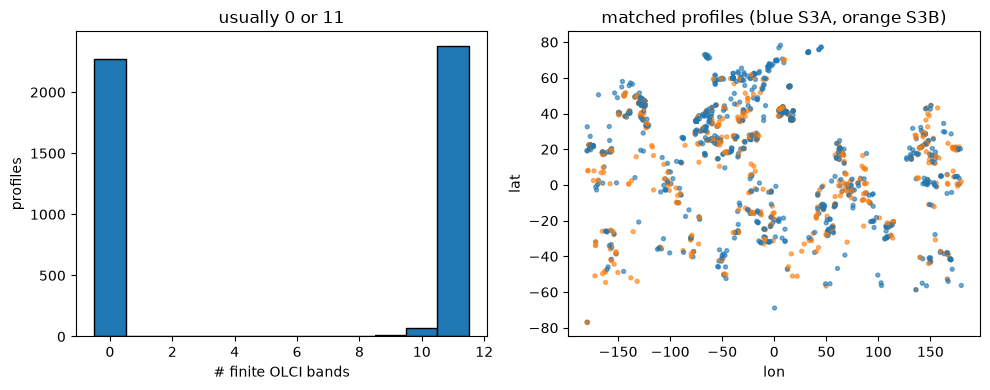

In [6]:
olci_cols = [f"olci_Rrs_{nm}" for nm in OLCI_BANDS]
df = pd.read_parquet(OUT) if OUT.exists() else acc
n = len(df)
n_any = int(df[olci_cols].notna().any(axis=1).sum())
n_all = int(df[olci_cols].notna().all(axis=1).sum())
n_bands = df[olci_cols].notna().sum(axis=1)

print(f"rows (unique profile_id): {n}")
print(f"any OLCI band finite:     {n_any}/{n}  ({100*n_any/n:.1f}%)")
print(f"all 11 bands finite:      {n_all}/{n}  ({100*n_all/n:.1f}%)")
print("sensor among matched:")
print(df.loc[df[olci_cols].notna().any(axis=1), "olci_sat"].value_counts(dropna=False))
print("\nby source:")
for src, sub in df.groupby("source"):
    k = int(sub[olci_cols].notna().all(axis=1).sum())
    print(f"  {src}: {k}/{len(sub)} all-11 ({100*k/len(sub):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(n_bands, bins=np.arange(-0.5, 12.5, 1), color="C0", edgecolor="k")
axes[0].set_xlabel("# finite OLCI bands")
axes[0].set_ylabel("profiles")
axes[0].set_title("usually 0 or 11")
matched = df[df[olci_cols].notna().any(axis=1)]
if len(matched):
    axes[1].scatter(
        matched["lon"], matched["lat"], s=8,
        c=matched["olci_sat"].map({"S3A": "C0", "S3B": "C1"}),
        alpha=0.6,
    )
axes[1].set_xlabel("lon")
axes[1].set_ylabel("lat")
axes[1].set_title("matched profiles (blue S3A, orange S3B)")
fig.tight_layout()